## INSTITUTO FEDERAL DO PIAUÍ
### Curso de Tecnologia em Geoprocessamento
### Disciplina: Introdução à Linguagem Python para Análise de Dados
### Prof. Dr. Reurysson Morais

___

Como citar: 
MORAIS, R. C. de S. **GEOP-Python para Análise de Dados**. Disponível em: [osf.io/8j6ng](https://osf.io/8j6ng/). DOI 10.17605/OSF.IO/8J6NG.
___
**AULA 12: Noções básicas de Pandas**

**Objetivo**: Demonstrar operações básicas com Séries e Dataframe do Pandas úteis para análise de dados.

**Recomendação:** Jupyter notebook adaptado de DSA (2024)


**Referências**

DSA - Data Science Academy. Fundamentos da Liguagem Python para Análise de Dados e Data Science. Disponível em> https://www.datascienceacademy.com.br/course/fundamentos-de-linguagem-python-para-analise-de-dados-e-data-science 

MCKINNEY, W. **Python para Análise de Dados**: tratamento de dados com Pandas, Numpy e Ipython. 3.ed. Trad. Aldir Coelho Corrêa da Silva. São Paulo: Novatec, 2023. Uma versão online gratuita está disponível em: https://wesmckinney.com/book/

Python.org. **Documentation**. v.3.14, 2025. Disponível em: https://docs.python.org/3.14/ .
___

**Estruturas de dados do Pandas**

- **Série**: é um objeto unidimensional semelhante a uma matriz que contém uma sequência de valores (de tipos semelhantes aos tipos NumPy) do mesmo tipo e uma matriz associada de rótulos de dados, chamada de *índice*.

- **DataFrame**: Representa uma tabela retangular de dados e contém uma coleção ordenada e nomeada de colunas, cada uma das quais pode ser de um tipo de valor diferente (numérico, string, booleano, etc.). O DataFrame possui um índice de linha e de coluna; pode ser considerado um dicionário de séries, todas compartilhando o mesmo índice.

### Importação do pacote Pandas

In [1]:
import pandas as pd

### Trabalhando com Series

In [2]:
# Criando uma Série com o Pandas
obj = pd.Series([4,7,-5,3])
obj

0    4
1    7
2   -5
3    3
dtype: int64

In [3]:
# Rotulando os índices 
obj2 = pd.Series([4,7,-5,3], index=["d", "b", "a", "c"])
obj2

d    4
b    7
a   -5
c    3
dtype: int64

In [4]:
# Criando Série a partir de um dicionário Pyhton
sdata = {"Ohio": 35000, "Texas": 71000, "Oregon": 16000, "Utah": 5000}

obj3 = pd.Series(sdata)
obj3

Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64

In [5]:
obj3.describe()

count        4.000000
mean     31750.000000
std      28952.547384
min       5000.000000
25%      13250.000000
50%      25500.000000
75%      44000.000000
max      71000.000000
dtype: float64

### Trabalhando com DataFrame 

In [6]:
# Criando um dicionário em Python
dados = {'Estado': ['Santa Catarina', 'Rio de Janeiro', 'Tocantins', 'Bahia', 'Minas Gerais'],
         'Ano':[2004, 2005, 2006, 2007, 2008],
         'Taxa Desemprego': [1.5, 1.7, 1.6, 2.4, 2.7]}

In [7]:
from pandas import DataFrame

In [8]:
# Convertendo um dicionário em um DataFrame Pandas 
df = DataFrame(dados)

In [9]:
# Visualizando as cinco primeiras linhas do df com o métido 'head()'
df.head()

,Estado,Ano,Taxa Desemprego
0,Santa Catarina,2004,1.5
1,Rio de Janeiro,2005,1.7
2,Tocantins,2006,1.6
3,Bahia,2007,2.4
4,Minas Gerais,2008,2.7


In [10]:
# Visualizando o tipo de dados
type(df)

pandas.core.frame.DataFrame

In [11]:
# Reorganizando as colunas ao converter um dicionário em um DataFrame
# Embora um df do Pandas aceite espaço no título das colunas é melhor evitar para poder usar métoddos de filtros e query mais rápidos
DataFrame(dados, columns= ['Estado', 'Taxa Desemprego', 'Ano'])

,Estado,Taxa Desemprego,Ano
0,Santa Catarina,1.5,2004
1,Rio de Janeiro,1.7,2005
2,Tocantins,1.6,2006
3,Bahia,2.4,2007
4,Minas Gerais,2.7,2008


In [12]:
# Criando um dataframe com os dados do dicionário criado anteriormento, com adição de uma nova coluna
# além da atribuição de palavras aos índices pandas

df2 = DataFrame(dados, columns= ['Estado', 'Taxa Desemprego', 'Taxa Crescimento','Ano'], 
                index= ['estado1','estado2','estado3','estado4','estado5'])

In [13]:
df2

,Estado,Taxa Desemprego,Taxa Crescimento,Ano
estado1,Santa Catarina,1.5,NaN,2004
estado2,Rio de Janeiro,1.7,NaN,2005
estado3,Tocantins,1.6,NaN,2006
estado4,Bahia,2.4,NaN,2007
estado5,Minas Gerais,2.7,NaN,2008


In [14]:
df2.values

array([['Santa Catarina', 1.5, nan, 2004],
       ['Rio de Janeiro', 1.7, nan, 2005],
       ['Tocantins', 1.6, nan, 2006],
       ['Bahia', 2.4, nan, 2007],
       ['Minas Gerais', 2.7, nan, 2008]], dtype=object)

In [15]:
df2.dtypes

Estado               object
Taxa Desemprego     float64
Taxa Crescimento     object
Ano                   int64
dtype: object

In [16]:
df2.columns

Index(['Estado', 'Taxa Desemprego', 'Taxa Crescimento', 'Ano'], dtype='object')

In [17]:
df2['Estado']

estado1    Santa Catarina
estado2    Rio de Janeiro
estado3         Tocantins
estado4             Bahia
estado5      Minas Gerais
Name: Estado, dtype: object

In [18]:
df2['Estado']['estado4']

'Bahia'

In [19]:
# Filtrando colunas específicas  - modo 1
df2[['Taxa Desemprego', 'Ano']]

,Taxa Desemprego,Ano
estado1,1.5,2004
estado2,1.7,2005
estado3,1.6,2006
estado4,2.4,2007
estado5,2.7,2008


In [20]:
# Filtrando colunas específicas  - modo 2
df2.filter(items=['Taxa Desemprego', 'Ano'])

,Taxa Desemprego,Ano
estado1,1.5,2004
estado2,1.7,2005
estado3,1.6,2006
estado4,2.4,2007
estado5,2.7,2008


In [21]:
df2.index

Index(['estado1', 'estado2', 'estado3', 'estado4', 'estado5'], dtype='object')

In [22]:
df2.filter(items=['estado1'], axis=0)

,Estado,Taxa Desemprego,Taxa Crescimento,Ano
estado1,Santa Catarina,1.5,NaN,2004


## Usando NumPy e Pandas para manipulação de dados

In [23]:
df2.describe()

,Taxa Desemprego,Ano
count,5.000000,5.000000
mean,1.980000,2006.000000
std,0.535724,1.581139
min,1.500000,2004.000000
25%,1.600000,2005.000000
50%,1.700000,2006.000000
75%,2.400000,2007.000000
max,2.700000,2008.000000


In [24]:
# Obtendo um resumo estatístico básico de cada coluna específica de um dataframe usando filtro 
df2.filter(items=['Taxa Desemprego']).describe()

,Taxa Desemprego
count,5.000000
mean,1.980000
std,0.535724
min,1.500000
25%,1.600000
50%,1.700000
75%,2.400000
max,2.700000


In [25]:
# Verificando de há valor ausendo no dataframe
df2.isna()

,Estado,Taxa Desemprego,Taxa Crescimento,Ano
estado1,False,False,True,False
estado2,False,False,True,False
estado3,False,False,True,False
estado4,False,False,True,False
estado5,False,False,True,False


In [26]:
import numpy as np

In [27]:
df2['Taxa Crescimento'] = np.arange(5.)

In [28]:
df2

,Estado,Taxa Desemprego,Taxa Crescimento,Ano
estado1,Santa Catarina,1.5,0.0,2004
estado2,Rio de Janeiro,1.7,1.0,2005
estado3,Tocantins,1.6,2.0,2006
estado4,Bahia,2.4,3.0,2007
estado5,Minas Gerais,2.7,4.0,2008


In [29]:
df2.dtypes

Estado               object
Taxa Desemprego     float64
Taxa Crescimento    float64
Ano                   int64
dtype: object

In [30]:
df2['Taxa Crescimento'].isna()

estado1    False
estado2    False
estado3    False
estado4    False
estado5    False
Name: Taxa Crescimento, dtype: bool

In [31]:
df2.describe()

,Taxa Desemprego,Taxa Crescimento,Ano
count,5.000000,5.000000,5.000000
mean,1.980000,2.000000,2006.000000
std,0.535724,1.581139,1.581139
min,1.500000,0.000000,2004.000000
25%,1.600000,1.000000,2005.000000
50%,1.700000,2.000000,2006.000000
75%,2.400000,3.000000,2007.000000
max,2.700000,4.000000,2008.000000


## Slicing do DataFrame do Pandas

In [32]:
df2

,Estado,Taxa Desemprego,Taxa Crescimento,Ano
estado1,Santa Catarina,1.5,0.0,2004
estado2,Rio de Janeiro,1.7,1.0,2005
estado3,Tocantins,1.6,2.0,2006
estado4,Bahia,2.4,3.0,2007
estado5,Minas Gerais,2.7,4.0,2008


In [33]:
# fatiamento: obtendo apenas a primeira linha do df
df2[:'estado1']

,Estado,Taxa Desemprego,Taxa Crescimento,Ano
estado1,Santa Catarina,1.5,0.0,2004


In [34]:
df2['estado2':'estado4']

,Estado,Taxa Desemprego,Taxa Crescimento,Ano
estado2,Rio de Janeiro,1.7,1.0,2005
estado3,Tocantins,1.6,2.0,2006
estado4,Bahia,2.4,3.0,2007


In [35]:
df2['estado3':]

,Estado,Taxa Desemprego,Taxa Crescimento,Ano
estado3,Tocantins,1.6,2.0,2006
estado4,Bahia,2.4,3.0,2007
estado5,Minas Gerais,2.7,4.0,2008


In [36]:
# Filtrando os dados de uma coluna específica com base em um valor
df2[ df2['Taxa Desemprego'] < 2]

,Estado,Taxa Desemprego,Taxa Crescimento,Ano
estado1,Santa Catarina,1.5,0.0,2004
estado2,Rio de Janeiro,1.7,1.0,2005
estado3,Tocantins,1.6,2.0,2006


## Preenchendo valores ausentes em datagframes do Pandas
A função fillna() é usanda para preencher valores ausentes. A função fornece muitas opções. Podemos usar um valor específicos, uma função agregada (por exemplo, média, moda, mediana) ou o valor anterior ou seguinte.

In [37]:
df3 = pd.read_csv('dados/tabela/dataset_pd.csv')

In [38]:
df3.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,NaN
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,NaN
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0
4,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2.0


In [39]:
# Verifica se há valores nulos (NaN) e soma todos eles 
df3.isna().sum()

ID_Pedido       0
Data_Pedido     0
ID_Cliente      0
Segmento        0
Pais            0
Regiao          0
ID_Produto      0
Categoria       0
Nome_Produto    0
Valor_Venda     0
Quantidade      2
dtype: int64

In [40]:
# Extrair a moda da coluna Quantidade - método não pythonic
moda = df3['Quantidade'].value_counts().index[0]
print(moda)
type(moda)

3.0


numpy.float64

In [41]:
# Extrair a moda da coluina Quantidade - método pythonic
# ATENÇÃO! Por algum motivo desconhecido por mim, esse método não poderá ser passado para substituir os valores NaN com o
# método 'fillna()'. Talvez seja  por causa do tipo de dado.
moda1 = df3['Quantidade'].mode()
print(moda1)
type(moda1)

0    3.0
Name: Quantidade, dtype: float64


pandas.core.series.Series

In [42]:
df3['Quantidade'].fillna(value = moda, inplace = True)

In [43]:
df3.isna().sum()

ID_Pedido       0
Data_Pedido     0
ID_Cliente      0
Segmento        0
Pais            0
Regiao          0
ID_Produto      0
Categoria       0
Nome_Produto    0
Valor_Venda     0
Quantidade      0
dtype: int64

In [44]:
df3

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,3.0
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0
4,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2.0
...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,TB-21400,Consumer,United States,South,FUR-FU-10001889,Furniture,Ultra Door Pull Handle,25.2480,3.0
9990,CA-2017-121258,2017-02-26,DB-13060,Consumer,United States,West,FUR-FU-10000747,Furniture,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2.0
9991,CA-2017-121258,2017-02-26,DB-13060,Consumer,United States,West,TEC-PH-10003645,Technology,Aastra 57i VoIP phone,258.5760,2.0
9992,CA-2017-121258,2017-02-26,DB-13060,Consumer,United States,West,OFF-PA-10004041,Office Supplies,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4.0


In [45]:
df3.isna().sum()

ID_Pedido       0
Data_Pedido     0
ID_Cliente      0
Segmento        0
Pais            0
Regiao          0
ID_Produto      0
Categoria       0
Nome_Produto    0
Valor_Venda     0
Quantidade      0
dtype: int64

## Query (Consulta) de dados do dataframe do Pandas

In [46]:
df3.head(2)

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.96,3.0
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0


In [47]:
# Obtendo o sumário estatístico de uma coluna específica
df3.Valor_Venda.describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Valor_Venda, dtype: float64

In [48]:
# Gerando um novo dataframe apenas com o intervalo de vendas entre 229 e 10000
df3_1 = df3.query('229 < Valor_Venda <10000')

In [49]:
df3_1.Valor_Venda.describe()

count    2357.000000
mean      766.679142
std       856.315136
min       229.544000
25%       323.100000
50%       490.320000
75%       859.200000
max      9892.740000
Name: Valor_Venda, dtype: float64

In [50]:
df3_2 = df3_1.query('Valor_Venda > 766')

In [51]:
df3_2.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0
7,CA-2014-115812,2014-06-09,BH-11710,Consumer,United States,West,TEC-PH-10002275,Technology,Mitel 5320 IP Phone VoIP phone,907.1520,6.0
10,CA-2014-115812,2014-06-09,BH-11710,Consumer,United States,West,FUR-TA-10001539,Furniture,Chromcraft Rectangular Conference Tables,1706.1840,9.0
11,CA-2014-115812,2014-06-09,BH-11710,Consumer,United States,West,TEC-PH-10002033,Technology,Konftel 250 Conference phone - Charcoal black,911.4240,4.0
24,CA-2015-106320,2015-09-25,EB-13870,Consumer,United States,West,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3.0


In [52]:
# Verificando o número de linhas e colunas de um dataframe
df3.shape

(9994, 11)

In [53]:
df3[df3['Quantidade'].isin([5,7,9,11])].head(10)

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0
5,CA-2014-115812,2014-06-09,BH-11710,Consumer,United States,West,FUR-FU-10001487,Furniture,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7.0
9,CA-2014-115812,2014-06-09,BH-11710,Consumer,United States,West,OFF-AP-10002892,Office Supplies,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5.0
10,CA-2014-115812,2014-06-09,BH-11710,Consumer,United States,West,FUR-TA-10001539,Furniture,Chromcraft Rectangular Conference Tables,1706.1840,9.0
14,US-2015-118983,2015-11-22,HP-14815,Home Office,United States,Central,OFF-AP-10002311,Office Supplies,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5.0
21,CA-2016-137330,2016-12-09,KB-16585,Corporate,United States,Central,OFF-AR-10000246,Office Supplies,Newell 318,19.4600,7.0
22,CA-2016-137330,2016-12-09,KB-16585,Corporate,United States,Central,OFF-AP-10001492,Office Supplies,"Acco Six-Outlet Power Strip, 4' Cord Length",60.3400,7.0
27,US-2015-150630,2015-09-17,TB-21520,Consumer,United States,East,FUR-BO-10004834,Furniture,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7.0
35,CA-2016-117590,2016-12-08,GH-14485,Corporate,United States,Central,TEC-PH-10004977,Technology,GE 30524EE4,1097.5440,7.0
36,CA-2016-117590,2016-12-08,GH-14485,Corporate,United States,Central,FUR-FU-10003664,Furniture,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5.0


## Operadores lógicos para manipulação de dados com Pandas

In [54]:
# Filtrando as vendas que ocorrem para o segmento de Home Office e na região South
df3[(df3.Segmento=='Home Office') & (df3.Regiao =='South')].head() # retorna o cinco primeiros elementos da lista

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
182,CA-2014-158274,2014-11-19,RM-19675,Home Office,United States,South,TEC-PH-10003273,Technology,AT&T TR1909W,503.9600,4.0
183,CA-2014-158274,2014-11-19,RM-19675,Home Office,United States,South,TEC-PH-10004896,Technology,Nokia Lumia 521 (T-Mobile),149.9500,5.0
184,CA-2014-158274,2014-11-19,RM-19675,Home Office,United States,South,TEC-AC-10002345,Technology,HP Standard 104 key PS/2 Keyboard,29.0000,2.0
231,US-2017-100930,2017-04-07,CS-12400,Home Office,United States,South,FUR-TA-10001705,Furniture,Bush Advantage Collection Round Conference Table,233.8600,2.0
232,US-2017-100930,2017-04-07,CS-12400,Home Office,United States,South,FUR-TA-10003473,Furniture,Bretford Rectangular Conference Table Tops,620.6145,3.0


In [55]:
# Filtrando as vendas que ocorrem para o segmento de Home Office ou para região South
df3[(df3.Segmento=='Home Office') | (df3.Regiao =='South')].tail()  # retorno os últimos elemetos da lista

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
9979,US-2016-103674,2016-12-06,AP-10720,Home Office,United States,West,OFF-BI-10002026,Office Supplies,Ibico Recycled Linen-Style Covers,437.472,14.0
9980,US-2015-151435,2015-09-06,SW-20455,Consumer,United States,South,FUR-TA-10001029,Furniture,KI Adjustable-Height Table,85.980,1.0
9987,CA-2017-163629,2017-11-17,RA-19885,Corporate,United States,South,TEC-AC-10001539,Technology,Logitech G430 Surround Sound Gaming Headset wi...,79.990,1.0
9988,CA-2017-163629,2017-11-17,RA-19885,Corporate,United States,South,TEC-PH-10004006,Technology,Panasonic KX - TS880B Telephone,206.100,5.0
9989,CA-2014-110422,2014-01-21,TB-21400,Consumer,United States,South,FUR-FU-10001889,Furniture,Ultra Door Pull Handle,25.248,3.0


In [56]:
# Filtrando as vendas que não ocorrem para o segmento de Home Office e nem na região South
df3[(df3.Segmento != 'Home Office') & (df3.Regiao !='South')].sample(5)  # retorna uma amostra de 5 valores

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
6314,CA-2014-100762,2014-11-24,NG-18355,Corporate,United States,Central,OFF-AR-10000380,Office Supplies,"Hunt PowerHouse Electric Pencil Sharpener, Blue",151.920,4.0
4286,CA-2015-105690,2015-11-21,CA-11965,Corporate,United States,Central,TEC-CO-10001571,Technology,Sharp 1540cs Digital Laser Copier,439.992,1.0
3315,CA-2017-169978,2017-12-24,HG-15025,Consumer,United States,East,OFF-BI-10001900,Office Supplies,"DXL Angle-View Binders with Locking Rings, Black",14.376,3.0
7222,CA-2017-113075,2017-09-02,MC-18100,Consumer,United States,Central,TEC-AC-10003441,Technology,Kingston Digital DataTraveler 32GB USB 2.0,40.680,3.0
7721,CA-2015-108588,2015-01-05,BG-11695,Corporate,United States,East,OFF-BI-10004506,Office Supplies,Wilson Jones data.warehouse D-Ring Binders wit...,13.168,2.0


## Agrupamentos de dados em dataframe Pandas com Group By

In [57]:
df3[['Segmento', 'Regiao', 'Valor_Venda']].groupby(['Segmento', 'Regiao']).mean()

Valor_Venda
Segmento    Regiao              
Consumer    Central   207.946728
            East      238.875539
            South     233.390180
            West      217.033955
Corporate   Central   234.763466
            East      228.516929
            South     238.992025
            West      235.265911
Home Office Central   208.248046
            East      253.911805
            South     272.996329
            West      239.442692

## Agregação Múltipla com Group By

In [58]:
df3[['Segmento', 'Regiao', 'Valor_Venda']].groupby(['Segmento', 'Regiao']).agg(['mean','std', 'median','count'])

Valor_Venda                           
                           mean          std  median count
Segmento    Regiao                                        
Consumer    Central  207.946728   587.906523  46.060  1212
            East     238.875539   633.371169  51.560  1469
            South    233.390180   559.346824  58.195   838
            West     217.033955   551.997547  59.520  1672
Corporate   Central  234.763466   818.947521  42.240   673
            East     228.516929   530.001654  59.900   877
            South    238.992025   586.176947  49.640   510
            West     235.265911   471.288764  69.468   960
Home Office Central  208.248046   371.009180  50.935   438
            East     253.911805   722.777318  52.715   502
            South    272.996329  1404.798466  55.785   272
            West     239.442692   529.242737  52.760   571

## Filtrando dataframe do Pandas com base em strings

In [59]:
# Retornando ao dataframe original
df3.head(3)

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.96,3.0
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0


In [60]:
# Filtrando o df pela coluna 'Segmento' com valores que iniciam com as letras 'Con'
df3[df3.Segmento.str.startswith('Con')].head(3)

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,3.0
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0


In [61]:
# Filtrando o df pela coluna 'Segmento' com valores que terminam com as letras 'mer'
df3[df3.Segmento.str.endswith('mer')].head(3)

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,3.0
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0


In [62]:
df3.ID_Pedido.head()

0    CA-2016-152156
1    CA-2016-152156
2    CA-2016-138688
3    US-2015-108966
4    US-2015-108966
Name: ID_Pedido, dtype: object

In [63]:
# Split da coluna ID_Pedido pelo caracter '-'.
df3.ID_Pedido.str.split('-')

0       [CA, 2016, 152156]
1       [CA, 2016, 152156]
2       [CA, 2016, 138688]
3       [US, 2015, 108966]
4       [US, 2015, 108966]
               ...        
9989    [CA, 2014, 110422]
9990    [CA, 2017, 121258]
9991    [CA, 2017, 121258]
9992    [CA, 2017, 121258]
9993    [CA, 2017, 119914]
Name: ID_Pedido, Length: 9994, dtype: object

In [64]:
# Split da coluna ID_Pedido pelo caracter '-'.
df3.ID_Pedido.str.split('-').str[1].head()

0    2016
1    2016
2    2016
3    2015
4    2015
Name: ID_Pedido, dtype: object

In [65]:
# Split da coluna ID_Pedido pelo caracter '-'.
df3.ID_Pedido.str.split('-').str[1].head()

0    2016
1    2016
2    2016
3    2015
4    2015
Name: ID_Pedido, dtype: object

In [66]:
# Criando uma nova conluna 'Ano' para receber os dados da divisão de uma coluna
df3['Ano'] = df3.ID_Pedido.str.split('-').str[1]

In [67]:
df3.head()

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,3.0,2016
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,2016
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,2016
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,2015
4,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2.0,2015


In [68]:
# Vamos remover os dígitos 2 e 0 à esquerda do valor da variável 'Data_Pedido'
df3.Data_Pedido.str.lstrip('20')

0       16-11-08
1       16-11-08
2       16-06-12
3       15-10-11
4       15-10-11
          ...   
9989    14-01-21
9990    17-02-26
9991    17-02-26
9992    17-02-26
9993    17-05-04
Name: Data_Pedido, Length: 9994, dtype: object

In [69]:
df3.head(3)

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano
0,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.96,3.0,2016
1,CA-2016-152156,2016-11-08,CG-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,2016
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,2016


## Replace (substituir) de strings em dataframe do Pandas
Se for necessário substituir caracteres dentro de uma string o Pandas pode fazer isso usando a função 'replace()'

In [70]:
# Substituindo dois caracteres da coluna 'ID_Cliente'
df3['ID_Cliente'] = df3.ID_Cliente.str.replace('CG', 'AX')

In [71]:
df3

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano
0,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.9600,3.0,2016
1,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,2016
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,2016
3,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,FUR-TA-10000577,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,2015
4,US-2015-108966,2015-10-11,SO-20335,Consumer,United States,South,OFF-ST-10000760,Office Supplies,Eldon Fold 'N Roll Cart System,22.3680,2.0,2015
...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,TB-21400,Consumer,United States,South,FUR-FU-10001889,Furniture,Ultra Door Pull Handle,25.2480,3.0,2014
9990,CA-2017-121258,2017-02-26,DB-13060,Consumer,United States,West,FUR-FU-10000747,Furniture,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2.0,2017
9991,CA-2017-121258,2017-02-26,DB-13060,Consumer,United States,West,TEC-PH-10003645,Technology,Aastra 57i VoIP phone,258.5760,2.0,2017
9992,CA-2017-121258,2017-02-26,DB-13060,Consumer,United States,West,OFF-PA-10004041,Office Supplies,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4.0,2017


## Combinação de strings em dataframe do Pandas


In [72]:
# Concatenação de strings em um nova coluna
df3['Pedido_Segmento'] = df3['ID_Pedido'].str.cat(df3['Segmento'], sep= '-')

In [73]:
df3.head(3)

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano,Pedido_Segmento
0,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.96,3.0,2016,CA-2016-152156-Consumer
1,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,2016,CA-2016-152156-Consumer
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,2016,CA-2016-138688-Corporate


## Renomeando colunas do Pandas

In [74]:
df3.rename(columns = {'Ano': 'Ano_Pedido'}, inplace=False).head(3)

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano_Pedido,Pedido_Segmento
0,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.96,3.0,2016,CA-2016-152156-Consumer
1,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,2016,CA-2016-152156-Consumer
2,CA-2016-138688,2016-06-12,DV-13045,Corporate,United States,West,OFF-LA-10000240,Office Supplies,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,2016,CA-2016-138688-Corporate


In [75]:
# Rwetornando ao dataframe original
df3.head(2)

,ID_Pedido,Data_Pedido,ID_Cliente,Segmento,Pais,Regiao,ID_Produto,Categoria,Nome_Produto,Valor_Venda,Quantidade,Ano,Pedido_Segmento
0,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.96,3.0,2016,CA-2016-152156-Consumer
1,CA-2016-152156,2016-11-08,AX-12520,Consumer,United States,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,2016,CA-2016-152156-Consumer


# Construção de gráficos a partir de dataframes do Pandas

In [76]:
# Importando o pacote scikit-learn
import sklearn

In [77]:
sklearn.__version__

'1.2.2'

In [78]:
from sklearn.datasets import load_iris
iris = load_iris()

In [79]:
df = DataFrame(iris['data'], columns = iris['feature_names'])
df['species'] = iris['target']
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
59,5.2,2.7,3.9,1.4,1
55,5.7,2.8,4.5,1.3,1
97,6.2,2.9,4.3,1.3,1
101,5.8,2.7,5.1,1.9,2
93,5.0,2.3,3.3,1.0,1


<Axes: >

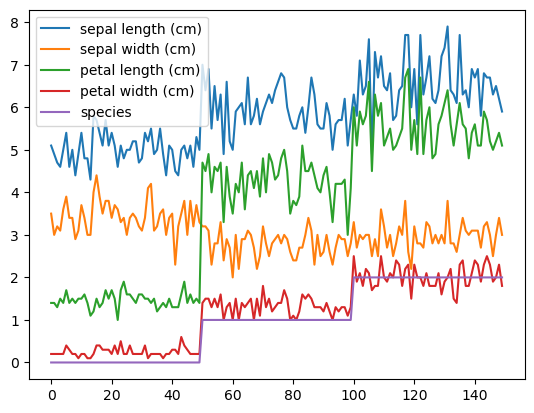

In [80]:
df.plot()

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

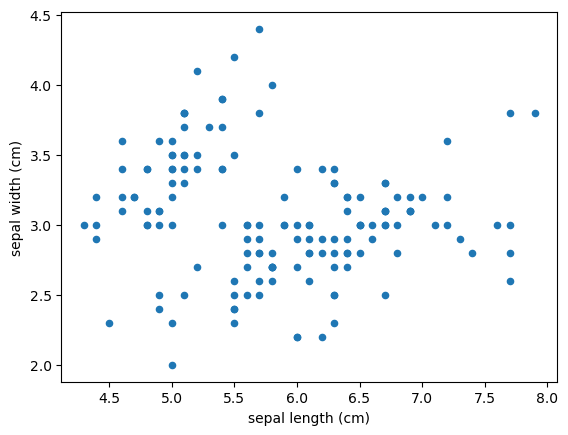

In [81]:
df.plot.scatter(x = 'sepal length (cm)', y = 'sepal width (cm)')

<Axes: >

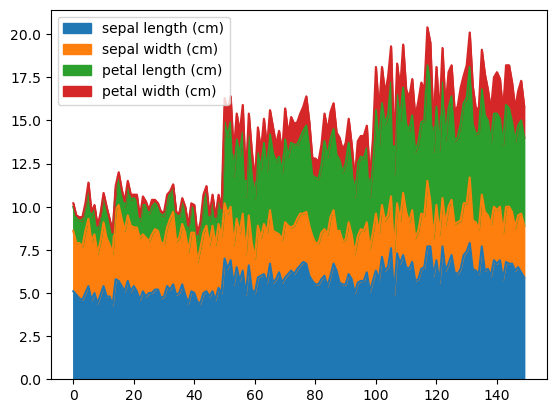

In [82]:
# Indicação apenas das colunas a serem plotadas no gráfico 
columns = ['sepal length (cm)',	'sepal width (cm)',	'petal length (cm)','petal width (cm)']
df[columns].plot.area()

<Axes: xlabel='species'>

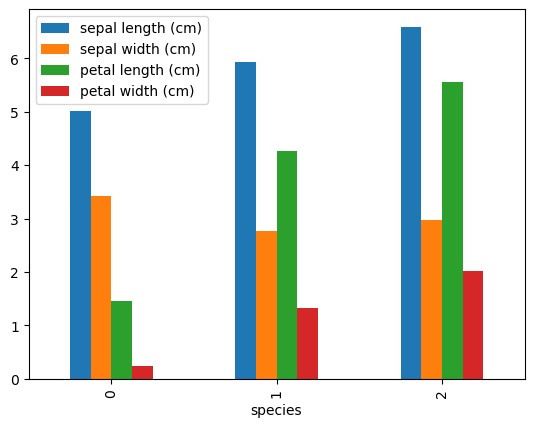

In [83]:
df.groupby('species').mean().plot.bar()

<Axes: ylabel='sepal length (cm)'>

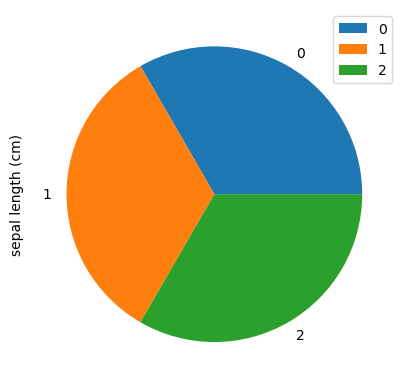

In [84]:
df.groupby('species').count().plot.pie(y = "sepal length (cm)")

<Axes: ylabel='Density'>

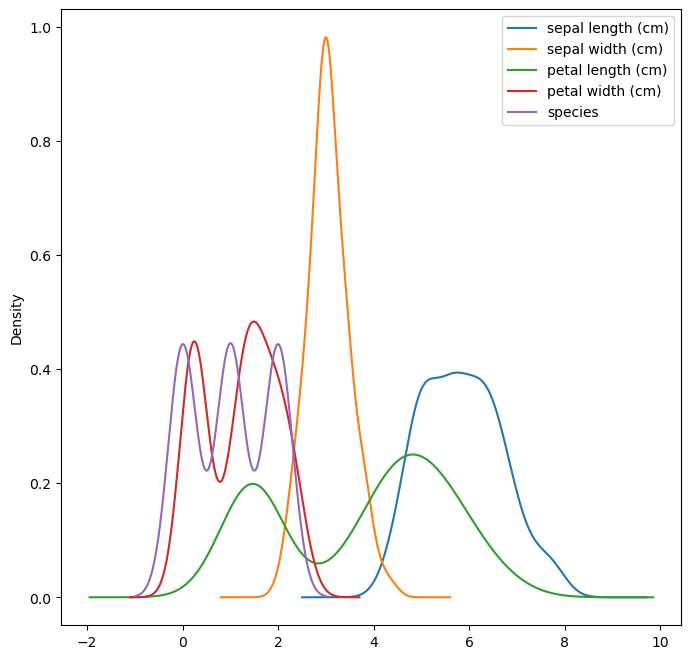

In [85]:
# Gráfico KDE (Kernel Density Function) para cada variável do dataframe
df.plot.kde(subplots = False, figsize = (8,8))

array([<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>], dtype=object)

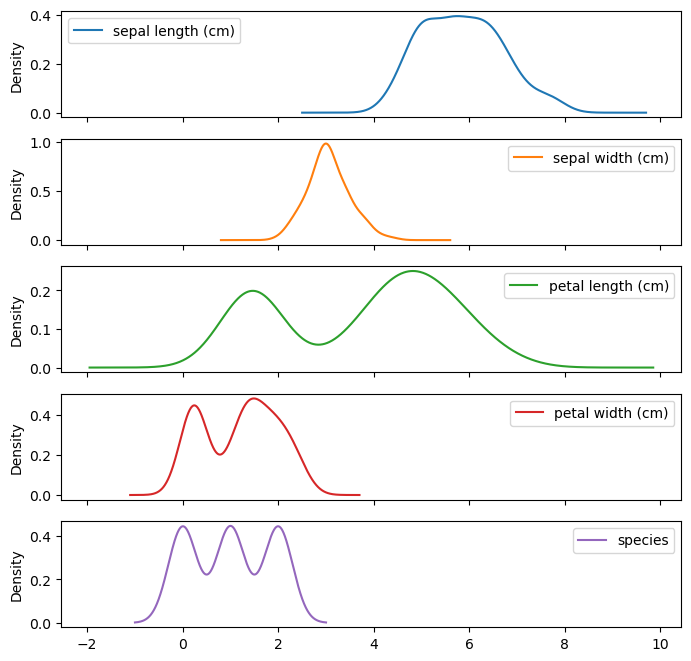

In [86]:
# Gráfico KDE (Kernel Density Function) para cada variável do dataframe
df.plot.kde(subplots = True, figsize = (8,8))

<Axes: >

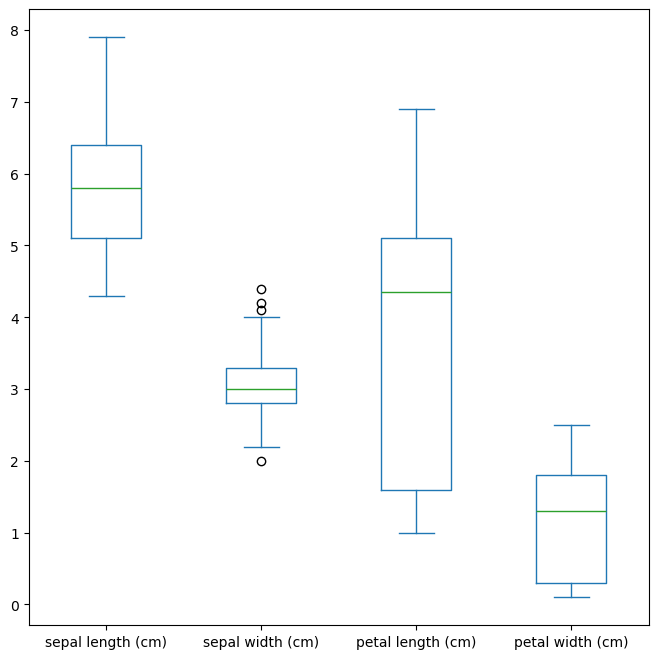

In [87]:

# Boxplor de cada variável numérica
columns = ['sepal length (cm)',	'sepal width (cm)',	'petal length (cm)','petal width (cm)']
df[columns].plot.box(figsize = (8,8))